# FloraDex — Flower Image Classification

UTS 32513 Advanced Data Analytics  
Assessment 2

## 1. Problem Definition

### Project idea

FloraDex is a proposed application concept inspired by a Pokédex for flowers, where users could photograph flowers they encounter and identify them.

For this assessment, the scope is limited to the machine-learning component of that concept: developing and evaluating a supervised multiclass image-classification model that predicts a flower class from an input photograph.

### Machine learning task

The problem is formulated as a supervised multiclass image classification task.

- **Input:** an image containing a flower
- **Output:** a predicted flower class
- **Target:** the true flower class associated with the image

The model therefore aims to learn a function:

\[
f(x) = y
\]

where \(x\) represents a flower image and \(y\) represents its flower class.

The project will investigate whether transfer learning can be used effectively to classify flowers from a relatively small labelled image dataset. A simpler baseline model will be used as a reference for comparison.

### Practical objective

The practical goal of FloraDex is to provide a reasonably reliable flower identification from a photograph. Model performance will therefore be evaluated not only through overall classification performance, but also by examining which flower classes the model confuses, how well it generalises to unseen images, and how confidently it makes predictions.

The model is treated as a proof-of-concept rather than a complete FloraDex system, because it will only be able to recognise the flower classes represented in the selected dataset.

## 2. Dataset Selection
  

### Selected dataset

The **Oxford 17 Category Flower Dataset** was selected for the FloraDex proof-of-concept.

The dataset contains:

- 17 flower categories
- 80 images per category
- 1,360 images in total

The images contain variation in pose, scale, lighting and appearance, creating a more realistic flower-classification problem than a highly controlled image dataset.

### Why this dataset was selected

The Oxford 17 dataset provides a balance between:

- relevance to the FloraDex concept
- technical challenge
- feasibility within the scope of A2

The TensorFlow Flowers dataset was also considered. It contains more images overall but only five flower classes, which would provide a simpler classification problem.

Oxford 17 was selected because its 17 classes make the task more representative of the FloraDex concept while remaining manageable for this assessment.

### Why transfer learning may be appropriate

Although Oxford 17 contains more flower categories, it provides only 80 labelled images for each class.

This means the model has relatively little data from which to learn the visual features of each flower category. Training a large convolutional neural network entirely from scratch may therefore increase the risk of overfitting.

This makes the dataset suitable for investigating **transfer learning**, where a model that has already learned general visual features from a much larger image dataset can be adapted to the FloraDex classification task.

The main investigation is therefore:

> **Can transfer learning produce a useful 17-class flower classifier from a relatively small labelled dataset?**

### Dataset trade-off

The main limitation of the dataset is its relatively small size.

With only 80 images per class, the training, validation and test sets will each contain a limited number of examples. This means that:

- overfitting may occur
- validation results may be more sensitive to the data split
- data augmentation may become important
- careful evaluation will be required

These challenges will form part of the model analysis rather than being treated only as limitations.

### Scope limitation

The resulting FloraDex model will only be able to classify the 17 flower categories represented in the Oxford dataset.

If an image contains a flower outside these categories, the model may still assign it to one of the known classes.

The model should therefore be considered a **proof-of-concept for the FloraDex machine-learning component**, rather than a comprehensive flower-identification system.

In [ ]:
# Oxford 17 dataset overview

NUM_CLASSES = 17
IMAGES_PER_CLASS = 80
TOTAL_IMAGES = NUM_CLASSES * IMAGES_PER_CLASS

print("Number of flower classes:", NUM_CLASSES)
print("Images per class:", IMAGES_PER_CLASS)
print("Total number of images:", TOTAL_IMAGES)

Number of flower classes: 17
Images per class: 80
Total number of images: 1360


## 3. Dataset Exploration

### Exploration objective

Before preprocessing or modelling, the dataset is inspected to understand its structure, class organisation, image characteristics and potential challenges.

The exploration will check:

- whether all expected images are present
- how the flower classes are represented
- image dimensions and formats
- examples from different classes
- variation in appearance, lighting, viewpoint and background

In [10]:
# Download the Oxford 17 flower image dataset

!wget -q https://www.robots.ox.ac.uk/~vgg/data/flowers/17/17flowers.tgz

print("Dataset downloaded.")

Dataset downloaded.


In [11]:
# Extract the downloaded dataset

!tar -xzf 17flowers.tgz

print("Dataset extracted.")

Dataset extracted.


In [12]:
import os

In [13]:
image_dir = "jpg"

image_files = [
    file for file in os.listdir(image_dir)
    if file.lower().endswith(".jpg")
]

print("Number of images found:", len(image_files))

Number of images found: 1360


### Class structure

The dataset contains 1,360 images distributed evenly across 17 flower classes, with 80 images in each class.

The image files are sequentially numbered, with each block of 80 images representing one flower category. Before using these labels for modelling, representative images from each group will be visually inspected to confirm that the expected class mapping is consistent with the dataset.

In [14]:
class_names = [
    "daffodil",
    "snowdrop",
    "lily_valley",
    "bluebell",
    "crocus",
    "iris",
    "tigerlily",
    "tulip",
    "fritillary",
    "sunflower",
    "daisy",
    "coltsfoot",
    "dandelion",
    "cowslip",
    "buttercup",
    "windflower",
    "pansy"
]

print("Number of classes:", len(class_names))

Number of classes: 17


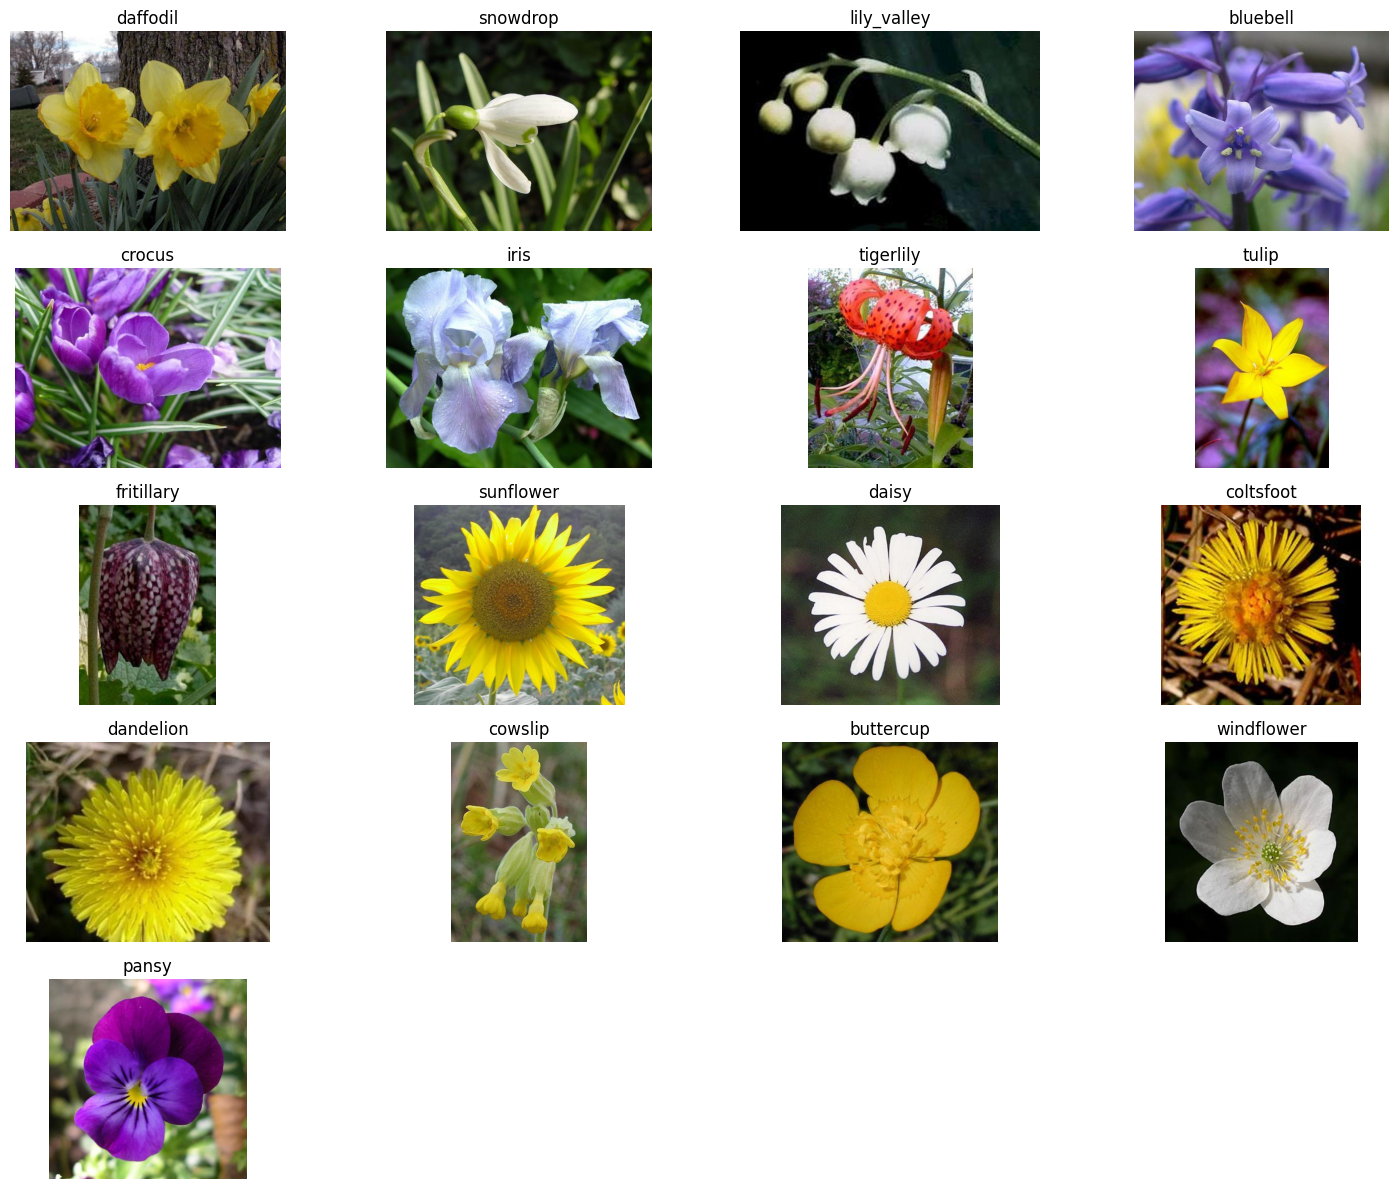

In [15]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(15, 12))

for class_index, class_name in enumerate(class_names):
  #First image belonging to each block of 80
  image_number = class_index * 80 + 1
  image_path = f"jpg/image_{image_number:04d}.jpg"

  image = Image.open(image_path)

  plt.subplot(5, 4, class_index + 1)
  plt.imshow(image)
  plt.title(class_name)
  plt.axis("off")

plt.tight_layout()
plt.show()

### Initial visual observations

A representative image from each of the 17 flower classes was inspected.

Several characteristics were observed:

- Some flower classes appear visually similar in colour or overall shape, which may make them harder for the model to distinguish.
- The sampled images are generally close-up photographs in which the flower occupies a large part of the image.
- Flowers appear mostly centred in the sampled images.
- Background complexity varies. Some images have relatively simple backgrounds, while others contain leaves, stems or other visual clutter.
- Lighting appears reasonably consistent across the sampled examples.
- Image clarity varies, with some photographs appearing sharper than others.

These characteristics may affect classification performance. In particular, visually similar classes and cluttered backgrounds may contribute to errors, while the generally close-up and centred composition could make the dataset easier than photographs captured in less controlled real-world conditions.

In [16]:
from PIL import Image
from collections import Counter

image_sizes = []

for file in image_files:
  image_path = os.path.join(image_dir, file)

  with Image.open (image_path) as image:
    image_sizes.append(image.size)

print("Number of images checked:", len(image_sizes))
print("Number of unique image sizes", len(set(image_sizes)))

Number of images checked: 1360
Number of unique image sizes 486


In [17]:
size_counts = Counter(image_sizes)

print("Most common image sizes:")

for size, count in size_counts.most_common(10):
  print(size, ":", count)

Most common image sizes:
(666, 500) : 258
(500, 666) : 68
(500, 500) : 55
(750, 500) : 24
(500, 750) : 23
(665, 500) : 18
(625, 500) : 16
(500, 751) : 15
(667, 500) : 13
(500, 667) : 10


In [18]:
widths = [width for width, height in image_sizes]
heights = [height for width, height in image_sizes]

print("Smallest width:", min(widths))
print("Largest width:", max(widths))

print("Smallest height:", min(heights))
print("Largest heght:", max(heights))

Smallest width: 499
Largest width: 1057
Smallest height: 499
Largest heght: 1093


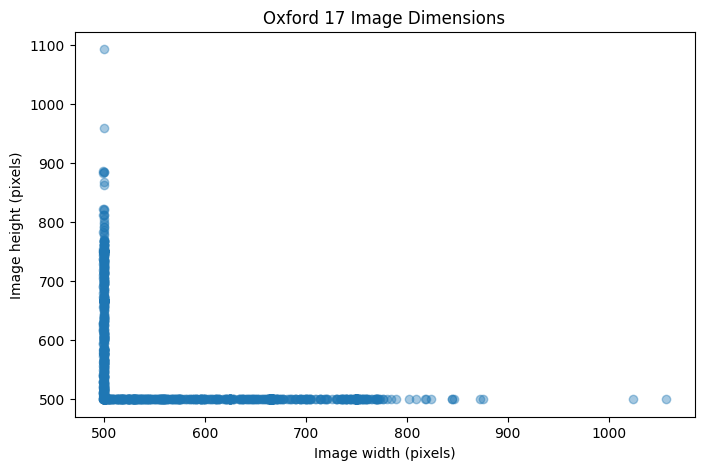

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(widths, heights, alpha=0.4)

plt.xlabel("Image width (pixels)")
plt.ylabel("Image height (pixels)")
plt.title("Oxford 17 Image Dimensions")

plt.show()

### Image dimension observations

The 1,360 images were inspected and found to have **486 unique image dimensions**, confirming that the dataset is not uniform in size.

Image widths range from **499 to 1057 pixels**, while image heights range from **499 to 1093 pixels**. The most common dimensions include approximately `666 × 500`, `500 × 666`, and `500 × 500`.

The scatter plot also shows a mixture of landscape, portrait and square image orientations.

Because convolutional neural networks require a consistent input shape for batched training, the images will need to be resized during preprocessing. The target size will be selected later based on the requirements of the chosen model.

In [20]:
from collections import Counter

image_modes = []

for file in image_files:
  image_path = os.path.join(image_dir, file)

  with Image.open(image_path) as image:
    image_modes.append(image.mode)

mode_counts = Counter(image_modes)
for mode, count in mode_counts.items():
  print(mode, ":", count)

RGB : 1360


### Colour mode

All 1,360 images are stored in RGB colour mode, meaning each image contains red, green and blue colour channels.

No grayscale or alternative colour modes were identified, so the dataset is consistent in terms of colour representation.

In [21]:
import random

random.seed(42)

plt.figure(figsize=(12, 34))

plot_index = 1

for class_index, class_name in enumerate(class_names):
  start_image = class_index * 80 + 1
  end_image = start_image + 79

  sampled_numbers = random.sample(
      range (start_image, end_image + 1),
      3
  )

  for image_number in sampled_numbers:
    image_path = f"jpg/image_{image_number:04d}.jpg"
    image = Image.open(image_path)

    plt.subplot(17, 3, plot_index)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

    plot_index += 1

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### Further visual observations

After inspecting multiple randomly sampled images from each class, the dataset appears to contain a reasonable amount of visual variation.

- Flowers are generally shown close-up, although some examples are off-centred.
- Some images contain multiple flowers rather than a single isolated flower.
- Backgrounds vary between relatively simple and visually cluttered scenes.
- Most classes show limited colour variation, although some classes contain more noticeable colour differences.
- Classes such as iris and fritillary appear more visually diverse than others.
- Some classes remain visually similar, particularly where flowers share similar colours or overall shapes.
- Unusual camera angles were not commonly observed.

These characteristics may influence model performance. Visually diverse classes may be harder to learn consistently, while similar-looking classes may be more likely to be confused during classification.

## 4. Data Preparation

### Train, validation and test strategy

The dataset will be divided into separate training, validation and test sets.

- **Training set:** used to optimise the model parameters.
- **Validation set:** used during model development to evaluate generalisation and guide modelling decisions.
- **Test set:** kept separate from model development and used only for final evaluation.

Because the Oxford 17 dataset is balanced with 80 images in each class, a stratified split will be used so that each flower class is represented proportionally in all three subsets.

A 70/15/15 split will be used, corresponding to approximately:

- 56 training images per class
- 12 validation images per class
- 12 test images per class

A fixed random seed will be used so that the split can be reproduced consistently.

In [22]:
import pandas as pd

records = []

for class_index, class_name in enumerate(class_names):
  start_image = class_index * 80 + 1
  end_image = start_image + 79

  for image_number in range (start_image, end_image + 1):
    filename = f"image_{image_number:04d}.jpg"
    image_path = os.path.join(image_dir, filename)

    records.append({
        "filename": filename,
        "image_path": image_path,
        "class_index": class_index,
        "class_name": class_name
    })

df = pd.DataFrame(records)

df.head()

,filename,image_path,class_index,class_name
0,image_0001.jpg,jpg/image_0001.jpg,0,daffodil
1,image_0002.jpg,jpg/image_0002.jpg,0,daffodil
2,image_0003.jpg,jpg/image_0003.jpg,0,daffodil
3,image_0004.jpg,jpg/image_0004.jpg,0,daffodil
4,image_0005.jpg,jpg/image_0005.jpg,0,daffodil


In [23]:
print("Total records:", len(df))
print("Number of classes:", df["class_name"].nunique())

df["class_name"].value_counts().sort_index()

Total records: 1360
Number of classes: 17


,count
class_name,
bluebell,80
buttercup,80
coltsfoot,80
cowslip,80
crocus,80
daffodil,80
daisy,80
dandelion,80
fritillary,80


In [24]:
from sklearn.model_selection import train_test_split

#First split:
#70% training, 30% temporary set
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class_name"],
    random_state=42
)

#Second split:
#Divide temporary set equally into validation and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class_name"],
    random_state=42
)

print("Training images:", len(train_df))
print("Validation Images:", len(val_df))
print("Test Images:", len(test_df))

Training images: 952
Validation Images: 204
Test Images: 204


In [25]:
split_counts = pd.DataFrame({
    "Train": train_df["class_name"].value_counts().sort_index(),
    "Validation": val_df["class_name"].value_counts().sort_index(),
    "Test": test_df["class_name"].value_counts().sort_index()
})

split_counts

,Train,Validation,Test
class_name,,,
bluebell,56,12,12
buttercup,56,12,12
coltsfoot,56,12,12
cowslip,56,12,12
crocus,56,12,12
daffodil,56,12,12
daisy,56,12,12
dandelion,56,12,12
fritillary,56,12,12


In [26]:
train_files = set(train_df["filename"])
val_files = set(val_df["filename"])
test_files = set(test_df["filename"])

print("Train/validation overlap:", len(train_files & val_files))
print("Train/test overlap", len(train_files & test_files))
print("Validation/test overlap:", len(val_files & test_files))

Train/validation overlap: 0
Train/test overlap 0
Validation/test overlap: 0


### Dataset split

The dataset was divided using a reproducible stratified 70/15/15 train, validation and test split.

This produced approximately:

- 952 training images
- 204 validation images
- 204 test images

Stratification was used to preserve the balanced class distribution across all three subsets. Each flower class therefore contributes approximately 56 training images, 12 validation images and 12 test images.

A fixed random seed (`random_state=42`) was used to ensure that the same split can be reproduced when the notebook is rerun.

The three subsets were also checked for overlapping filenames, confirming that no image appears in more than one subset. This reduces the risk of data leakage between model training and evaluation.

### Preprocessing requirements identified

Dataset exploration identified several preprocessing requirements before model training:

- The images have varying dimensions and therefore require a consistent input size.
- All images are already stored in RGB colour mode, so no colour-mode conversion is currently required.
- The target image dimensions will be selected based on the input requirements of the model architecture chosen for training.
- Data augmentation will be considered because the dataset contains only 80 original images per class and may be susceptible to overfitting.

These preprocessing steps will be implemented before model training.

### Input representation

All images will be resized to **224 × 224 pixels** with three RGB colour channels.

This provides a consistent input shape for batched neural-network training and is also compatible with many common pretrained CNN architectures.

### Image preprocessing

MobileNetV2 expects images with a consistent spatial size and RGB colour channels.

All Oxford 17 images will therefore be resized to:

\[
224 \times 224 \times 3
\]

where the three channels correspond to red, green and blue.

The MobileNetV2-specific preprocessing function will also be applied before images are passed into the pretrained network. This transforms pixel values into the numerical range expected by the pretrained model.

Using the preprocessing associated with MobileNetV2 ensures that the FloraDex images are represented in a way that is compatible with the features learned during ImageNet pretraining.

### Data augmentation

Data augmentation will be applied only to the training set.

Because the dataset contains only 56 original training images per flower class, augmentation can increase the visual variation seen during training and may help reduce overfitting.

The planned transformations are:

- small random rotations
- horizontal flips
- small zoom changes
- small horizontal and vertical translations

These transformations are intended to simulate plausible variation in real flower photographs without changing the underlying flower class.

Validation and test images will not be augmented so that model performance is measured on unmodified unseen examples.

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = (224, 224)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    )
], name="data_augmentation")

### TensorFlow dataset pipeline

In [28]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_prepare_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)

    return image, label

In [29]:
def create_dataset(dataframe, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["image_path"].values,
        dataframe["class_index"].values
    ))

    dataset = dataset.map(
        load_and_prepare_image,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [30]:
train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

print("Datasets created.")

Datasets created.


In [31]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First few labels:", labels[:10].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
First few labels: [ 6  6  8  7 11  9  3  4  4 11]


## 5. Baseline Model

### Hypothesis family

The baseline model will be a relatively small convolutional neural network (CNN) trained from scratch.

This means the model must learn its visual features directly from the Oxford 17 training images rather than relying on features learned from another dataset.

The baseline provides a reference point for the main transfer-learning approach.

The comparison asks:

> Can transfer learning provide better flower-image classification than a CNN learning visual features from scratch, given the limited FloraDex training data?

### Model architecture

The baseline is a small convolutional neural network trained from scratch.

Its purpose is to provide a simple reference model that must learn flower-specific visual features only from the Oxford 17 training data.

The network uses three convolutional blocks with increasing numbers of filters:

- 32 filters
- 64 filters
- 128 filters

Each convolutional layer is followed by max pooling to reduce the spatial size of the feature maps while retaining important visual information.

The extracted features are then summarised using global average pooling and passed through a dense classification layer before producing probabilities across the 17 flower classes.

The architecture is intentionally kept relatively simple so that it remains an appropriate baseline rather than competing with the pretrained transfer-learning model on complexity alone.

In [33]:
NUM_CLASSES = 17

baseline_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

In [34]:
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,953 (437.32 KB)

 Trainable params: 111,953 (437.32 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Transfer Learning Model

### Selected architecture

The main model will use **MobileNetV2** as a pretrained convolutional neural network.

MobileNetV2 was selected because it provides a strong balance between image-classification capability and computational efficiency. It is considerably lighter than architectures such as ResNet50, making it suitable for a relatively small dataset and a Colab-based assessment workflow.

The model will use weights learned previously from the ImageNet dataset. These pretrained layers provide general visual features such as edges, textures and shapes.

For FloraDex, the pretrained feature-extraction layers will initially be frozen, and a new classification head will be trained to predict the 17 Oxford flower classes.

This allows the project to compare:

- a CNN learning all visual features from scratch
- a model reusing previously learned visual features through transfer learning

### Initial strategy

The pretrained MobileNetV2 base will initially remain frozen during training.

Only the newly added FloraDex classification layers will be updated.

This provides a controlled first transfer-learning experiment and reduces the risk of overfitting the pretrained weights to the relatively small Oxford 17 training set.

Fine-tuning selected pretrained layers may be investigated later if the initial model shows evidence that further adaptation could improve generalisation.

### Model architecture

In [35]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [36]:
base_model.trainable = False

In [37]:
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

transfer_model = keras.Model(
    inputs,
    outputs,
    name="floradex_mobilenetv2"
)

In [38]:
transfer_model.summary()

Model: "floradex_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 17)             │        21,777 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,279,761 (8.70 MB)

 Trainable params: 21,777 (85.07 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Connection to representation learning

MobileNetV2 does not classify the flower directly from the raw image pixels. Instead, its pretrained convolutional layers transform the input image into a learned visual representation.

After the MobileNetV2 feature extractor, each image is represented by 1,280 high-level feature values following global average pooling. These features capture useful visual patterns learned previously from ImageNet, such as shapes, textures and structural information.

The final FloraDex classification layer then uses this learned representation to predict one of the 17 flower classes.

This demonstrates representation learning: rather than manually defining flower features, the model learns a useful internal representation of the image that can support the downstream classification task.

## 7. Training

### Training configuration

Because FloraDex is a 17-class classification problem, the final output layer will contain 17 units with a softmax activation function.

Softmax converts the model outputs into a probability distribution across the 17 flower classes.

The model will be trained using sparse categorical cross-entropy loss. This is appropriate because each image has one integer class label and the task is multiclass classification.

The Adam optimiser will be used with an initial learning rate of 0.001 for the baseline model.

Training will begin with a maximum of 30 epochs and early stopping will be used to stop training if validation performance no longer improves.

### Baseline training

In [39]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [40]:
baseline_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [41]:
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[baseline_early_stopping]
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - accuracy: 0.0830 - loss: 2.8235 - val_accuracy: 0.1176 - val_loss: 2.7569
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.1103 - loss: 2.6559 - val_accuracy: 0.1422 - val_loss: 2.4868
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.1271 - loss: 2.4971 - val_accuracy: 0.1618 - val_loss: 2.4042
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.1733 - loss: 2.3731 - val_accuracy: 0.2549 - val_loss: 2.2323
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.2479 - loss: 2.2113 - val_accuracy: 0.3431 - val_loss: 2.0394
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.2794 - loss: 2.0930 - val_accuracy: 0.3922 - val_loss: 1.9623
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.3067 - loss: 1.9790 - val_accuracy: 0.3725 - val_loss: 1.9574
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.3151 - loss: 1.9507 - val_accuracy: 0.4265 - val_lo

### Baseline curves

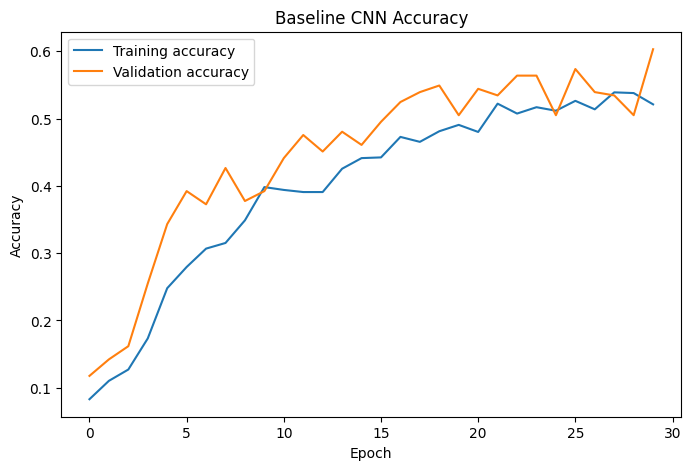

In [57]:
history = baseline_history.history

plt.figure(figsize=(8, 5))

plt.plot(history["accuracy"], label="Training accuracy")
plt.plot(history["val_accuracy"], label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy")
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/floradex_baseline_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

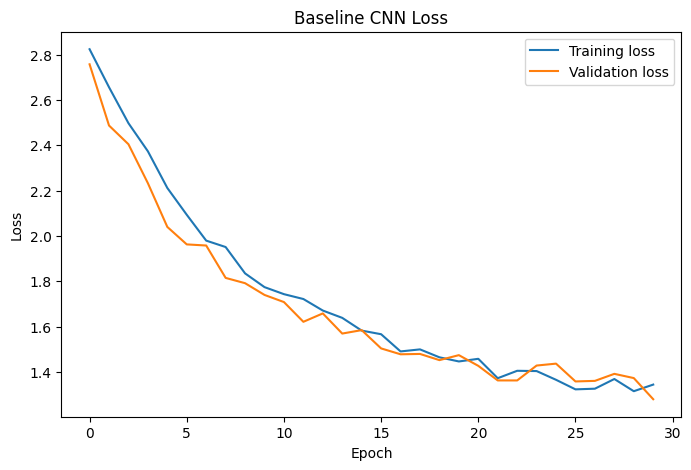

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(history["loss"], label="Training loss")
plt.plot(history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/floradex_baseline_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [46]:
baseline_model.save("/content/drive/MyDrive/floradex_baseline_cnn.keras")

### Baseline interpretation

The baseline CNN shows clear evidence of learning across the 30 training epochs.

Training and validation accuracy generally increased together, while both training and validation loss decreased substantially. Validation accuracy reached approximately 60%, considerably above the approximately 5.9% accuracy expected from random guessing across 17 equally likely classes.

There is currently no strong evidence of severe overfitting because validation loss generally decreases alongside training loss and validation accuracy does not progressively diverge from training accuracy.

Validation accuracy is occasionally higher than training accuracy. This is reasonable because data augmentation and dropout are active during training, making the training examples more difficult, while validation is performed on unchanged images with dropout disabled.

The baseline therefore provides a meaningful reference point for determining whether MobileNetV2 transfer learning can achieve stronger generalisation on the same classification problem.

### Transfer-learning training

In [49]:
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [50]:
transfer_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [51]:
transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[transfer_early_stopping]
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.3067 - loss: 2.2521 - val_accuracy: 0.6422 - val_loss: 1.3812
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.7164 - loss: 1.0758 - val_accuracy: 0.7598 - val_loss: 0.8660
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8015 - loss: 0.7240 - val_accuracy: 0.8333 - val_loss: 0.6421
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.8645 - loss: 0.5241 - val_accuracy: 0.8627 - val_loss: 0.5404
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8918 - loss: 0.4238 - val_accuracy: 0.8725 - val_loss: 0.4815
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9128 - loss: 0.3758 - val_accuracy: 0.8824 - val_loss: 0.4586
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9191 - loss: 0.3154 - val_accuracy: 0.9069 - val_loss: 0.4010
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9401 - loss: 0.2735 - val_accuracy: 0.9020 - val_loss:

### Transfer-learning curves

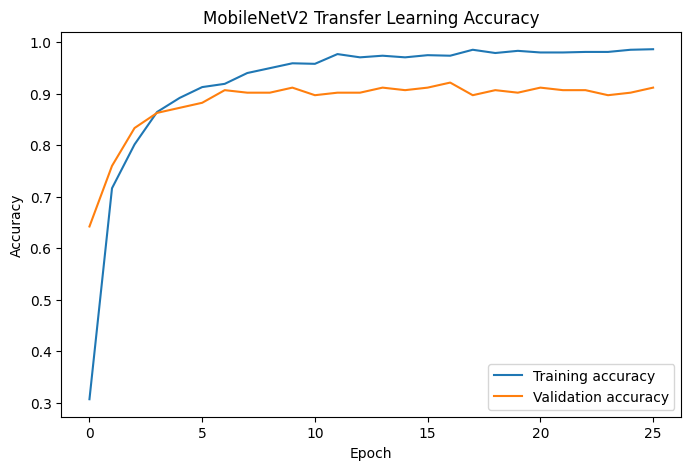

In [59]:
transfer_hist = transfer_history.history

plt.figure(figsize=(8, 5))

plt.plot(transfer_hist["accuracy"], label="Training accuracy")
plt.plot(transfer_hist["val_accuracy"], label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 Transfer Learning Accuracy")
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/floradex_mobilenetv2_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

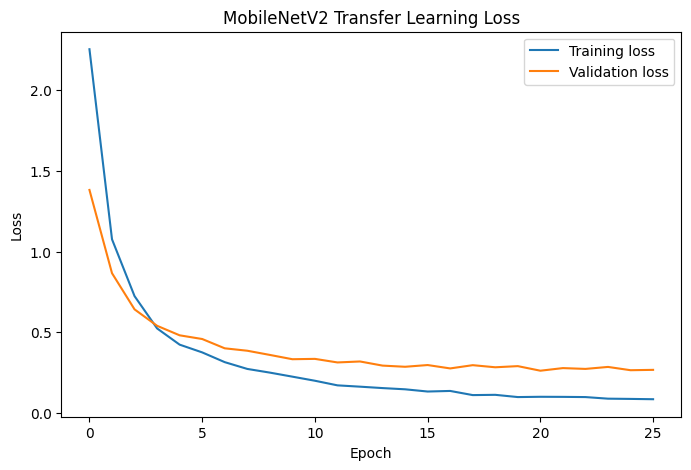

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(transfer_hist["loss"], label="Training loss")
plt.plot(transfer_hist["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 Transfer Learning Loss")
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/floradex_mobilenetv2_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
transfer_model.save("/content/drive/MyDrive/floradex_mobilenetv2.keras")

In [67]:
!git clone https://github.com/emelinachow-lgtm/FloraDex.git

Cloning into 'FloraDex'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 18 (delta 5), reused 7 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 5.54 KiB | 1.38 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [68]:
%cd /content/FloraDex

/content/FloraDex


In [69]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [71]:
!find /content/drive/MyDrive -name "floradex_a2.ipynb"

/content/drive/MyDrive/Colab Notebooks/floradex_a2.ipynb


In [72]:
!cp "/content/drive/MyDrive/Colab Notebooks/floradex_a2.ipynb"

cp: missing destination file operand after '/content/drive/MyDrive/Colab Notebooks/floradex_a2.ipynb'
Try 'cp --help' for more information.


### Transfer-learning interpretation

MobileNetV2 learned the Oxford 17 classification task substantially faster than the baseline CNN.

Training accuracy increased rapidly and eventually approached 99%, while validation accuracy reached approximately 89%. Validation accuracy exceeded 80% within the first few epochs, demonstrating that the pretrained ImageNet features transferred effectively to the flower-classification task.

A generalisation gap becomes visible later in training. Training loss continues to decrease while validation loss begins to flatten at approximately 0.28–0.30, and training accuracy remains several percentage points above validation accuracy.

This suggests some overfitting to the training data. However, validation performance remains strong, indicating that the pretrained representation still generalises substantially better than the CNN trained from scratch.

### Initial model comparison

The first comparison shows a substantial performance difference between the two hypothesis families.

The baseline CNN, which learned all visual features from the Oxford 17 training data, reached approximately 61% validation accuracy.

In contrast, the MobileNetV2 transfer-learning model reached approximately 89% validation accuracy and learned the task much more rapidly.

This suggests that the pretrained ImageNet features provide useful visual representations that transfer effectively to the FloraDex flower-classification task.

The transfer-learning model also required fewer newly trainable parameters than the baseline model because most of the MobileNetV2 feature-extraction network remained frozen.

Although MobileNetV2 shows a larger gap between training and validation performance, its validation accuracy remains substantially higher than the baseline. This indicates that transfer learning currently provides much stronger generalisation for the relatively small Oxford 17 dataset.

These results support the initial investigation question:

> **Can transfer learning provide better flower-image classification than a model learning visual features from scratch, given FloraDex's limited training data?**

Based on the initial validation results, the answer is yes.

## 8. Evaluation

### Final test-set evaluation

## 9. Error Analysis

## 10. Practical FloraDex Considerations

## 11. Limitations

## 12. Conclusion